In [1]:
from plastic_neuron import PlasticNeuron
from abstract_neuron import AbstractNeuron
from neuron_utils import NeuronUtils
from neuron_plots import NeuronPlots
import matplotlib.pyplot as plt
from neuron import h
import numpy as np
import pandas as pd

# Subthreshold LTP without the electric field

The neuron has 10 synapses. All synapses receive potentiating inputs of 100 Hz for 1000 ms, starting at 1000 ms and ending at 2000 ms.

The test stimulus (a single stimulus to all synapses) is provided at 100 ms (before LTP protocol) and at 2500 ms (after LTP protocol).

Goal: find such a conductance that after providing a test stimulus to all synapses, it would not elicit APs neither before nor after the LTP protocol without the electric field. This conductance can be different for different synapse configurations.

In [2]:
test_stimulus_1 = 100
test_stimulus_2 = 2500

In [3]:
idx = 4
conductances = [ format(i, ".6f") for i in np.arange(0.00005, 0.0001 + 0.000005, 0.000005) ]

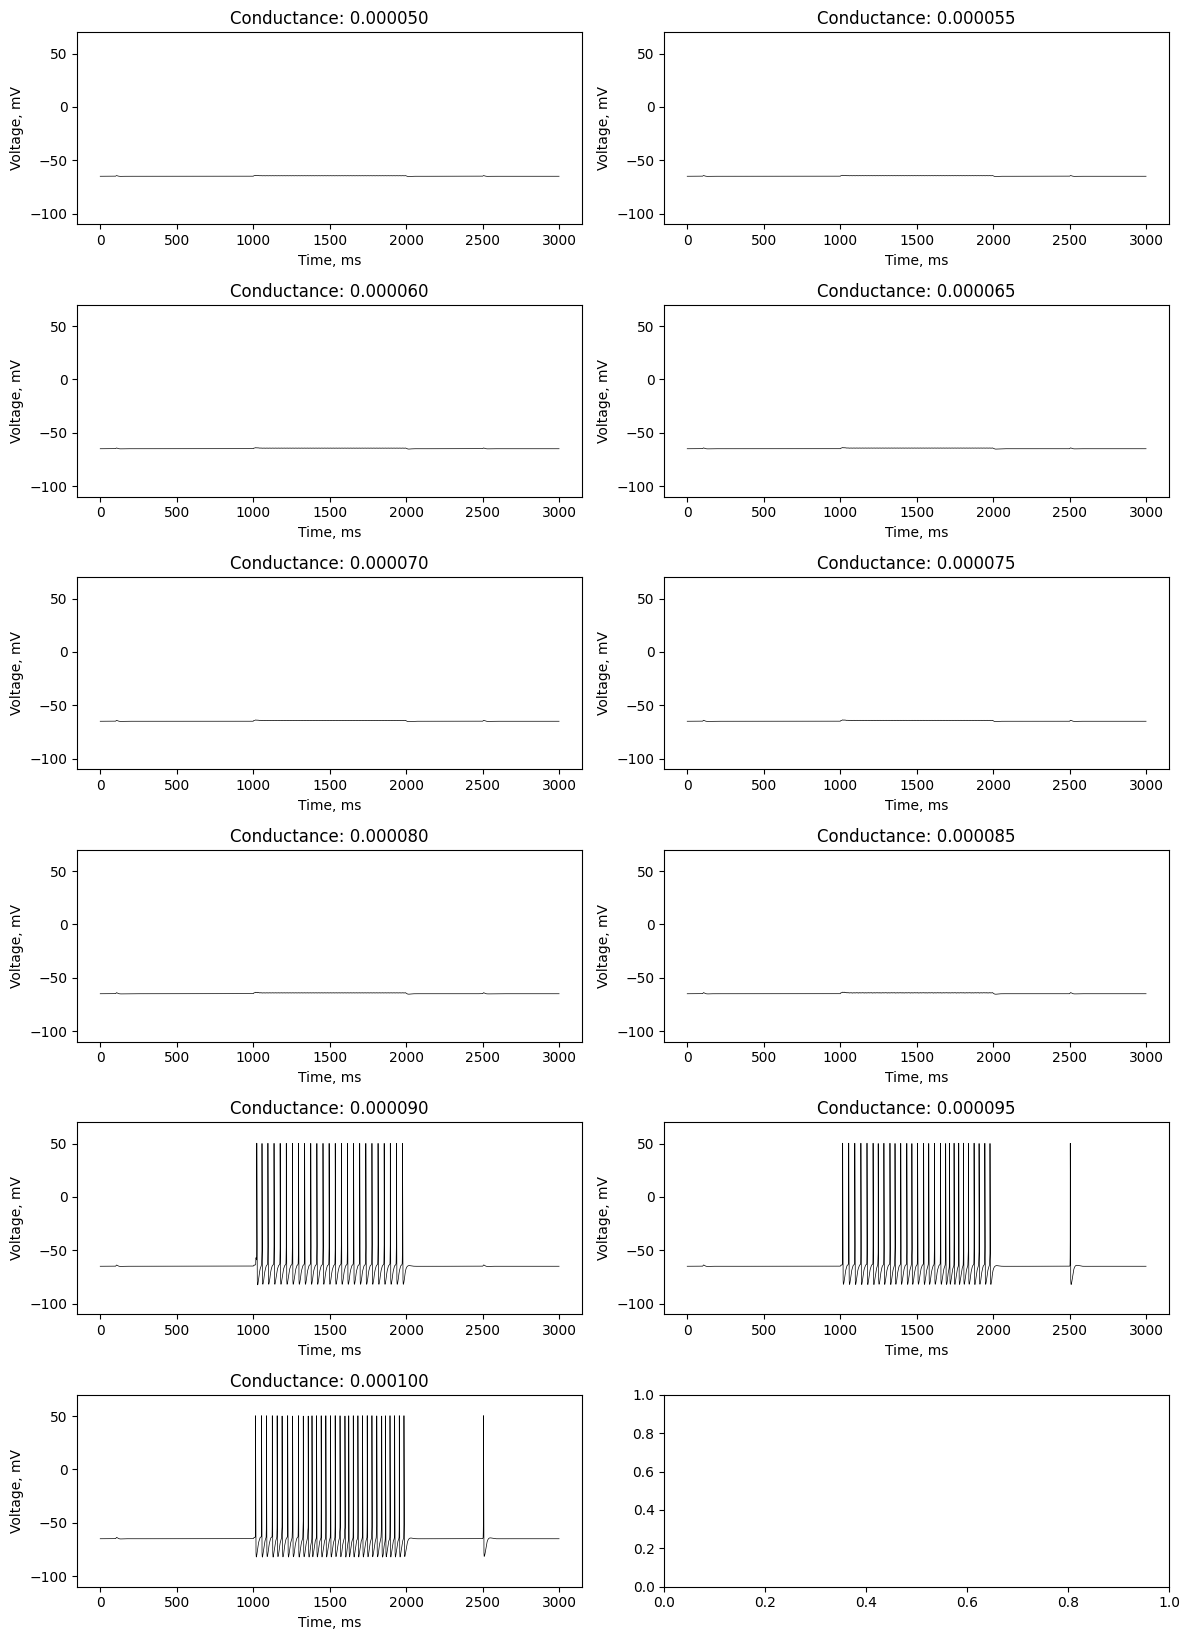

In [4]:
fig, axs = plt.subplots(nrows = int(np.ceil(len(conductances) / 2)), ncols = 2, figsize = (12, len(conductances) * 1.5))
axs = axs.flatten()

for conductance, ax in zip(conductances, axs):
    voltage = pd.read_csv(f"output/temporal-interference/conductance_ltp/{idx}/{conductance}/voltage.csv")

    ax.plot(
        voltage.Time,
        voltage.Voltage,
        linewidth = 0.5,
        color = "black"
    )

    epsp_1 = np.array(voltage.Voltage[np.where(np.logical_and(voltage.Time > test_stimulus_1 - 50, voltage.Time < test_stimulus_1 + 150))[0]].tolist())
    epsp_2 = np.array(voltage.Voltage[np.where(np.logical_and(voltage.Time > test_stimulus_2 - 50, voltage.Time < test_stimulus_2 + 150))[0]].tolist())

    spike_before = np.any(epsp_1 > -20)
    spike_after = np.any(epsp_2 > -20)

    ax.set_xlabel("Time, ms")
    ax.set_ylabel("Voltage, mV")
    ax.set_title(f"Conductance: {conductance}")
    ax.set_ylim(-110, 70)

fig.tight_layout()
plt.show()

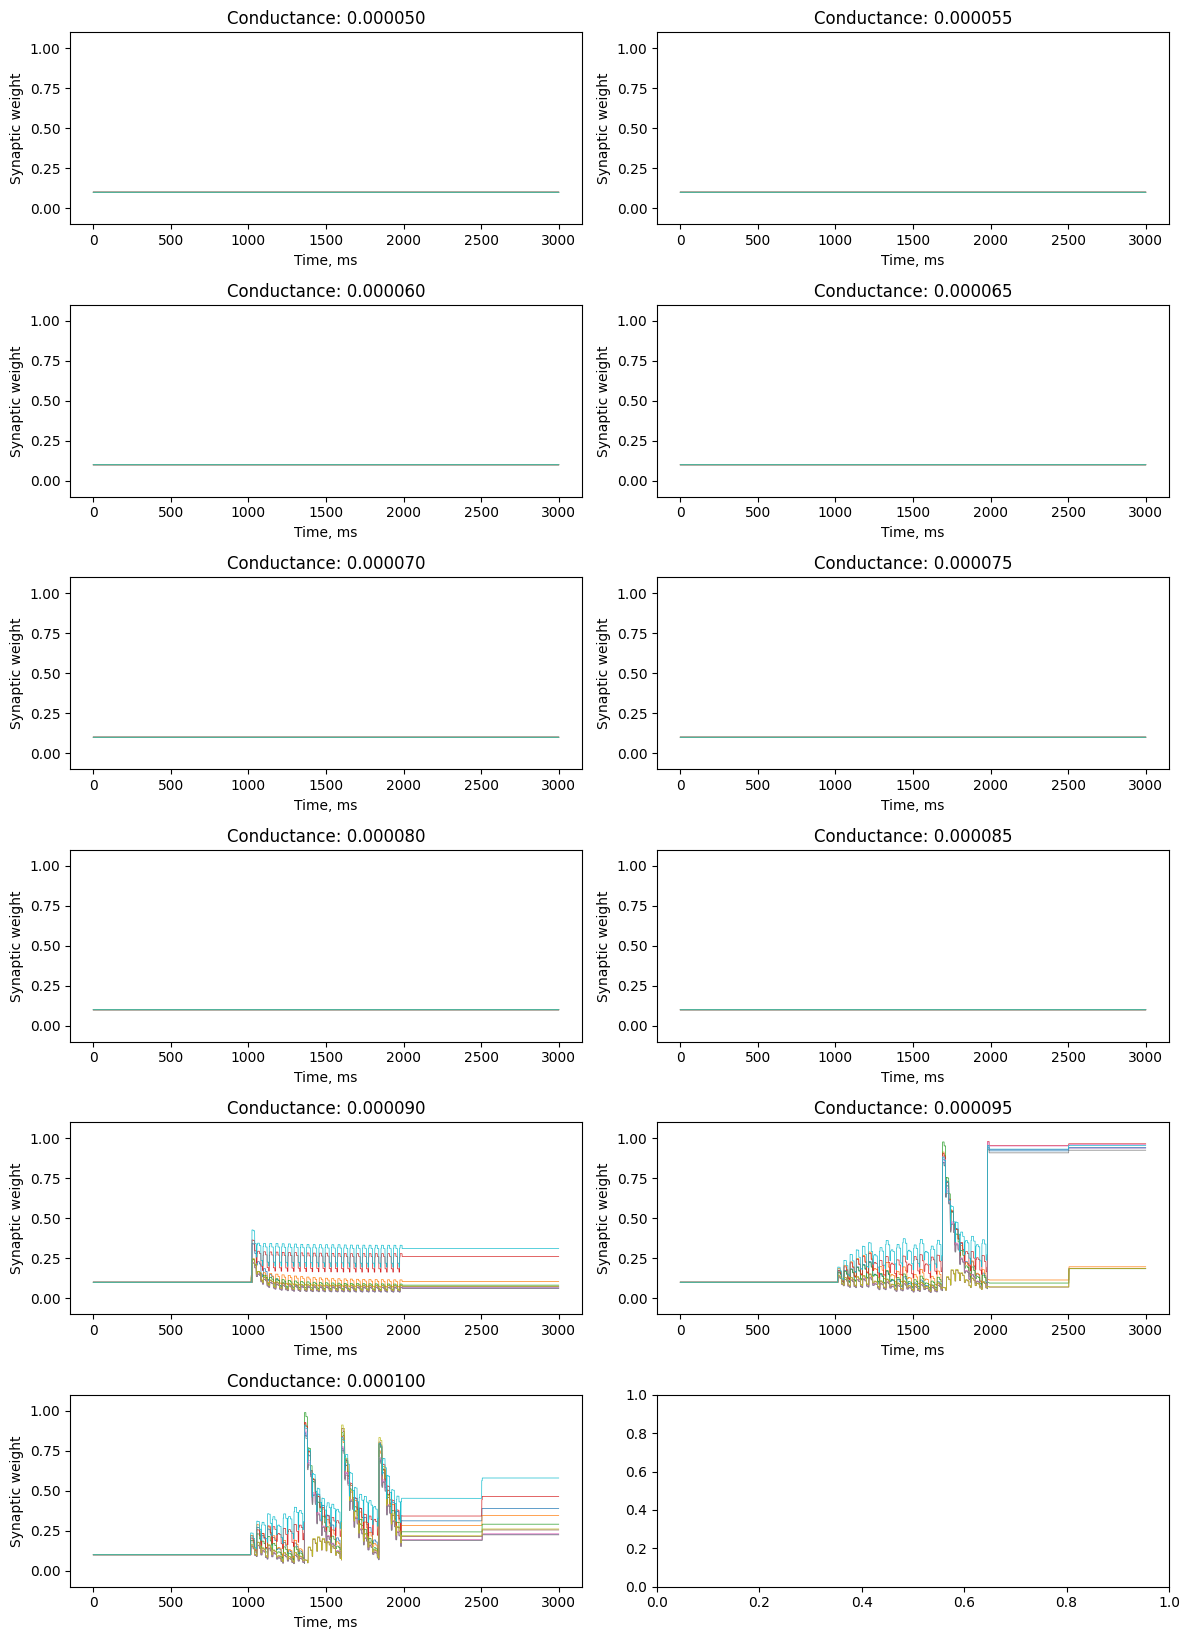

In [5]:
fig, axs = plt.subplots(nrows = int(np.ceil(len(conductances) / 2)), ncols = 2, figsize = (12, len(conductances) * 1.5))
axs = axs.flatten()

for conductance, ax in zip(conductances, axs):
    weights = []
    time = []

    synapse_weights = pd.read_csv(f"output/temporal-interference/conductance_ltp/{idx}/{conductance}/synapse_weights.csv", index_col = 0)
    synapses = [ f"Synapse{i}" for i in range(0, 10) ]
    
    for synapse in synapses:
        ax.plot(
            synapse_weights.Time,
            synapse_weights[synapse],
            linewidth = 0.5
        )
    
    ax.set_ylim(-0.1, 1.1)
    ax.set_title(f"Conductance: {conductance}")
    ax.set_xlabel("Time, ms")
    ax.set_ylabel("Synaptic weight")
    ax.grid(False)

fig.tight_layout()
plt.show()

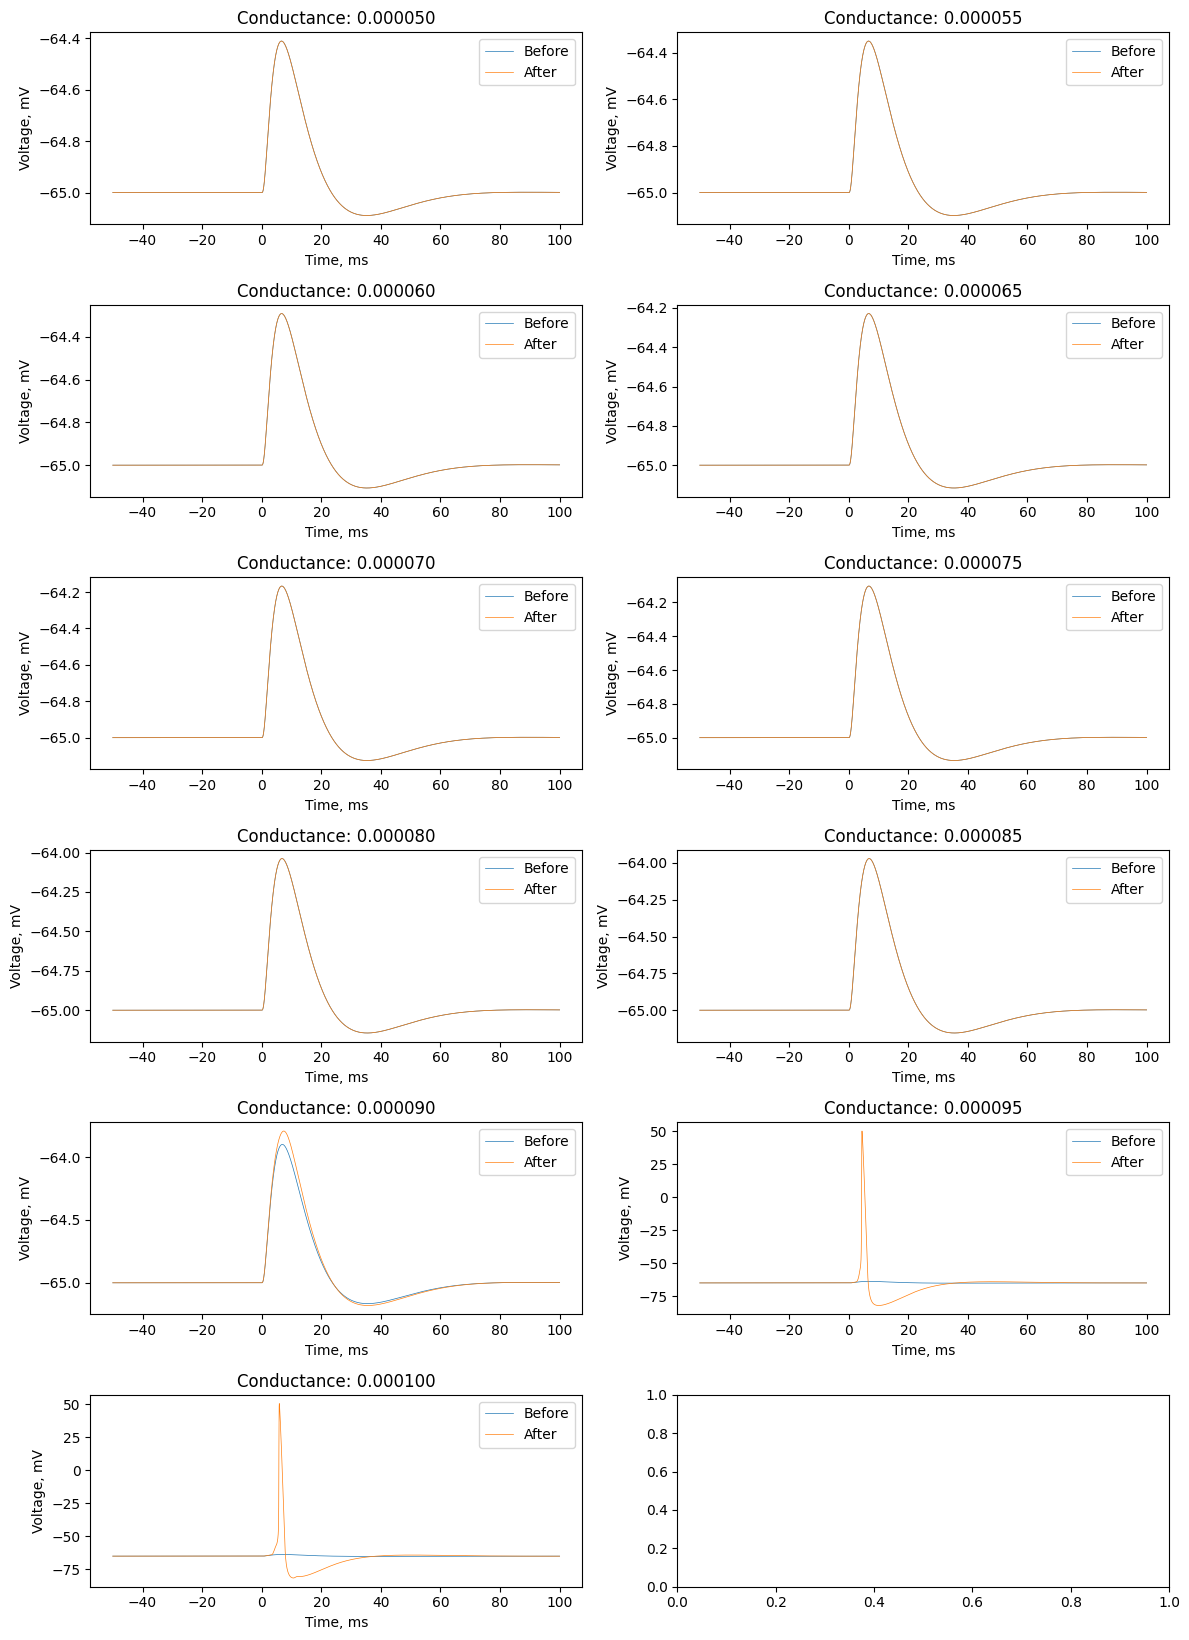

In [6]:
time_before = 50
time_after = 100

fig, axs = plt.subplots(nrows = int(np.ceil(len(conductances) / 2)), ncols = 2, figsize = (12, len(conductances) * 1.5))
axs = axs.flatten()

for conductance, ax in zip(conductances, axs):
    voltage = pd.read_csv(f"output/temporal-interference/conductance_ltp/{idx}/{conductance}/voltage.csv")

    epsp_before = np.array(voltage.Voltage[np.where(np.logical_and(voltage.Time > test_stimulus_1 - time_before, voltage.Time < test_stimulus_1 + time_after))[0]].tolist())
    epsp_after = np.array(voltage.Voltage[np.where(np.logical_and(voltage.Time > test_stimulus_2 - time_before, voltage.Time < test_stimulus_2 + time_after))[0]].tolist())

    time = np.arange(-time_before, time_after + 0.025, 0.025)
    
    ax.set_ylabel("Voltage, mV")
    ax.set_xlabel("Time, ms")
    ax.plot(
        time[:len(epsp_before)],
        epsp_before,
        label = "Before",
        linewidth = 0.5
    )
    ax.plot(
        time[:len(epsp_after)],
        epsp_after,
        label = "After",
        linewidth = 0.5
    )

    ax.set_title(f"Conductance: {conductance}")
    ax.legend(loc = "upper right")
    ax.grid(False)

fig.tight_layout()
plt.show()